## Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings(action='ignore')

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load Data

In [5]:
df = pd.read_csv(r"C:\Users\mahar\OneDrive\Pictures\문서\All Data sets\housing (1).csv")

In [6]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


### Understand Data

In [8]:
df.shape

(20640, 9)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 1.4 MB


In [10]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [11]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200


In [12]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700
20639,-121.24,39.37,16,2785,616.0,1387,530,2.3886,89400


In [13]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
dtype: int64

In [14]:
df.duplicated().sum()

0

In [15]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [16]:
df.isnull().sum()*100

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

In [17]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [18]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age      int64
total_rooms             int64
total_bedrooms        float64
population              int64
households              int64
median_income         float64
median_house_value      int64
dtype: object

In [19]:
x= df.drop("median_house_value", axis=1)
y=df["median_house_value"]

# EDA

### Histogram

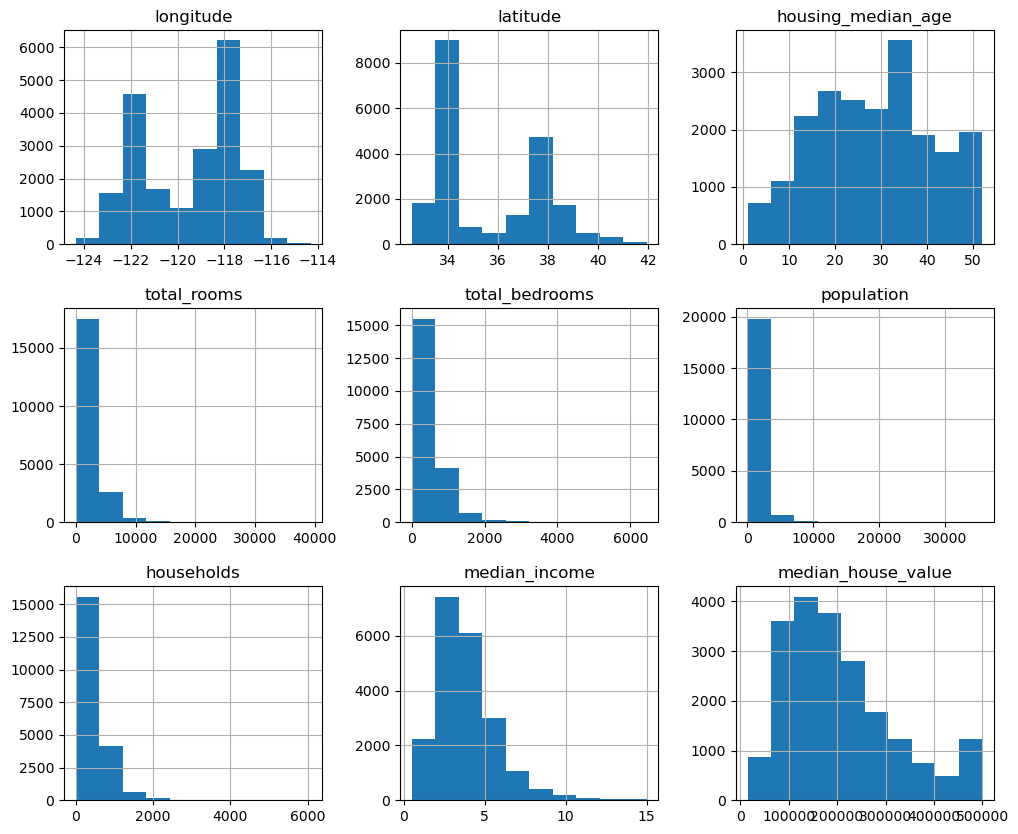

In [22]:
df.hist(figsize=(12,10))
plt.show()

Insights:
* Most of the values are low,and only a few values are very high(Right-skewed)
* Median Income has a very a few high values(Outliers)
* Most house prices are less than 50000

### Boxplot

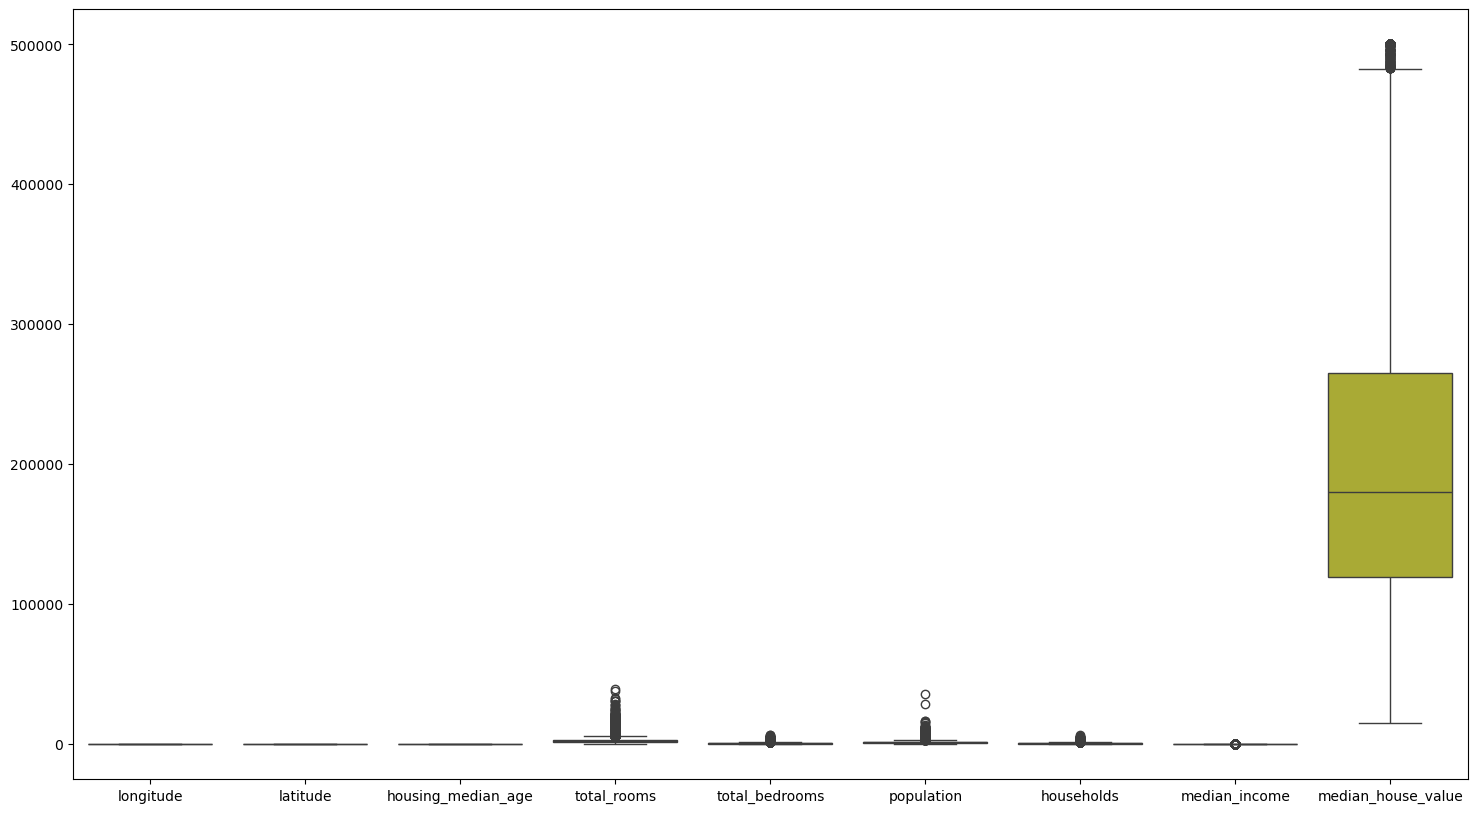

In [25]:
plt.figure(figsize=(18,10))
sns.boxplot(data=df)
plt.show()

Insights:
* Many outliers exist.
* Total rooms and population have extreme values.
* Median income also contains outliers.

### CountPlot

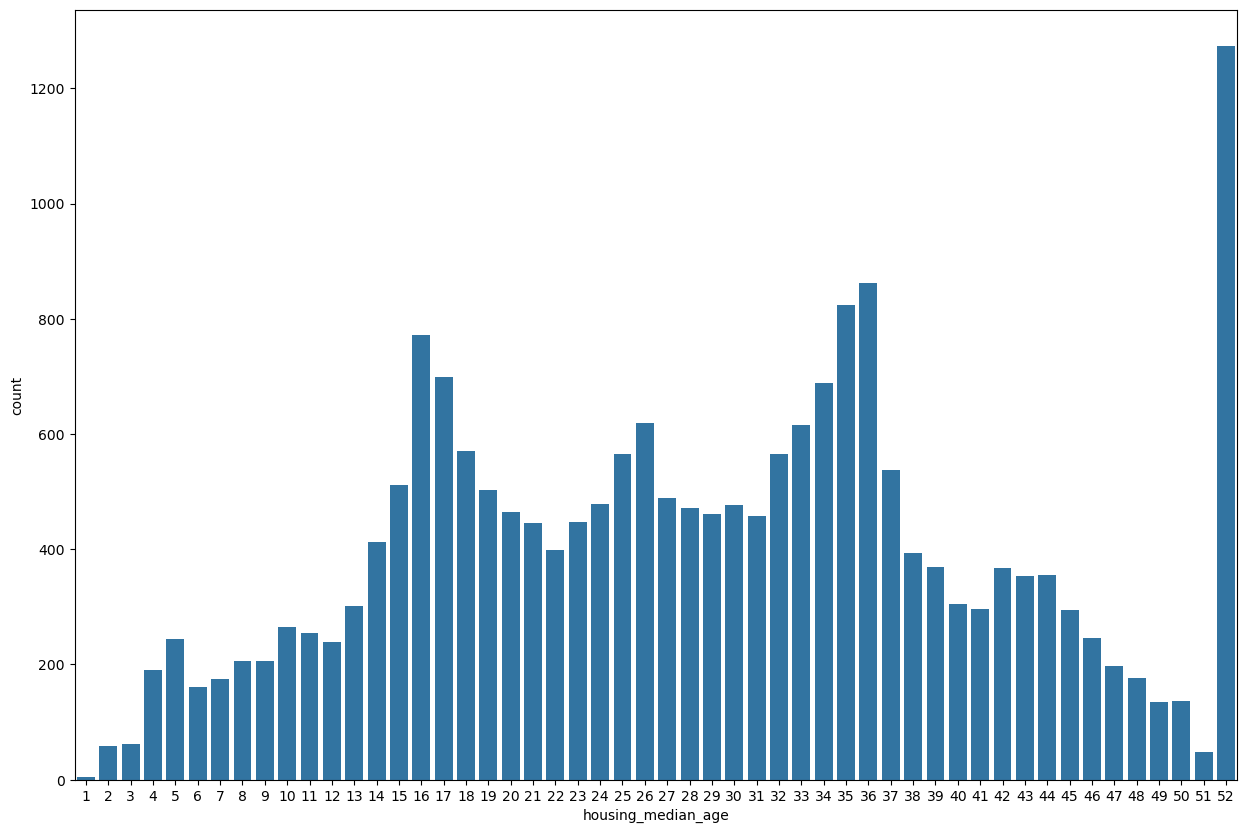

In [28]:
# Since there is no categorical feature, use housing age.
plt.figure(figsize=(15,10))
sns.countplot(x="housing_median_age",data=df)
plt.show()

insights:
* Some house ages appear more frequently
* Older houses are common

### Correlation Heatmap

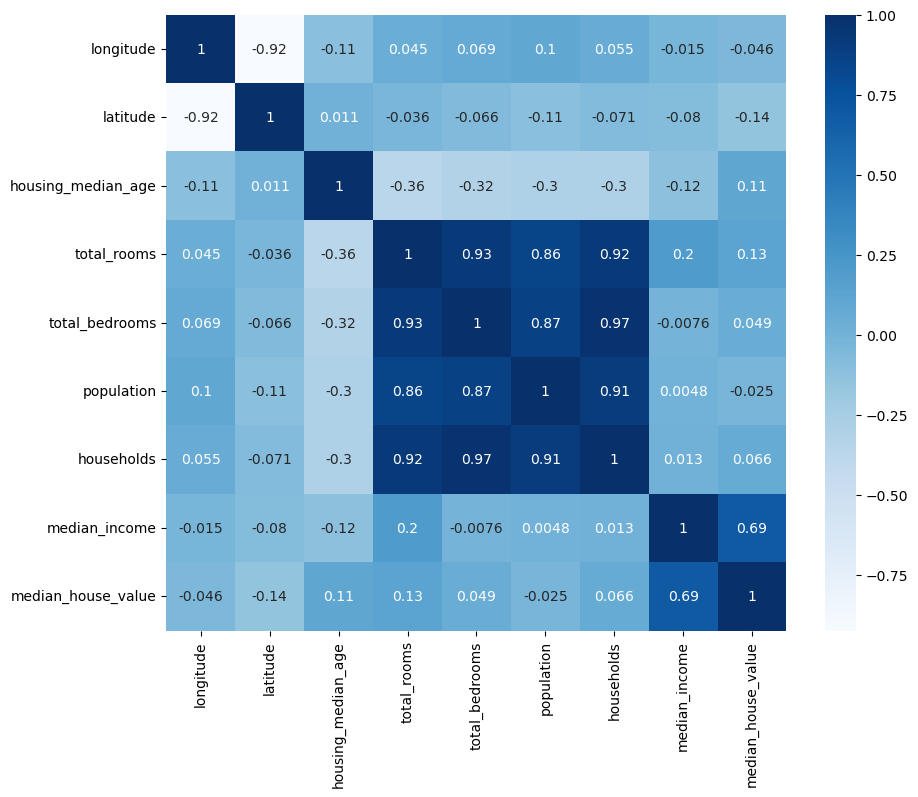

In [31]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="Blues")
plt.show()

insights:
* Median income has the highest positive correlation with house price.
* Latitude,longitude and population show negative relationships.
* Housing_median_age,total_rooms and households show week positve correlation
* toatal_bedrooms have very week positive correlation

### Scatter Plot

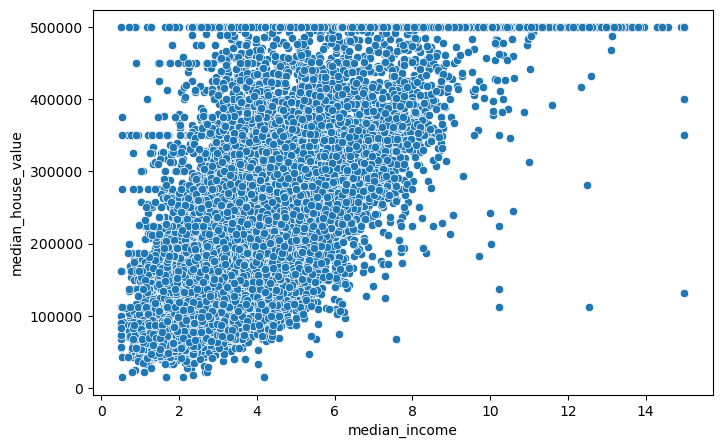

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="median_income",y="median_house_value",data=df)
plt.show()

Insigths:
* As median_income increases house prices also increases
* Higher-icome have expensive houses
* most house prices are below 500000

### Handling Outliers

In [37]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)

IQR=Q3-Q1

df=df[~((df<(Q1-1.5*IQR)) | (df>(Q3+1.5*IQR)))]

## Feature Scaling

In [39]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [40]:
# Feature Selection
corr=df.corr()["median_house_value"].sort_values(ascending=False)
print(corr)

median_house_value    1.000000
median_income         0.626620
total_rooms           0.184548
households            0.113662
total_bedrooms        0.091674
housing_median_age    0.061480
population            0.017072
longitude            -0.047342
latitude             -0.149100
Name: median_house_value, dtype: float64


In [41]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Linear Regression

In [43]:
lr=LinearRegression()
lr.fit(x_train,y_train)
lr_pred=lr.predict(x_test)

In [44]:
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score :", r2_score(y_test,lr_pred))

MAE : 51810.48362804243
MSE : 5059928371.1653385
RMSE : 71133.17349286012
R2 Score : 0.613866475643519


# Decision Tree

In [46]:
dt=DecisionTreeRegressor(random_state=42)
dt.fit(x_train,y_train)
dt_pred=dt.predict(x_test)

In [47]:
lr=[]
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("MSE :", mean_squared_error(y_test, dt_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score :", r2_score(y_test, dt_pred))

MAE : 44299.31904069767
MSE : 4881778541.9546995
RMSE : 69869.725503645
R2 Score : 0.6274614549338615


# Random Forest

In [49]:
rf=RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)
rf_pred=rf.predict(x_test)

In [50]:
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

MAE : 32093.6485876938
MSE : 2488059936.8590016
RMSE : 49880.456462015274
R2 Score : 0.8101310370904977


### Comparison Table

In [52]:
results=pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],

    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],

    'MSE': [
        mean_squared_error(y_test, lr_pred),
        mean_squared_error(y_test, dt_pred),
        mean_squared_error(y_test, rf_pred)
    ],

    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],

    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})
results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,51810.483628,5.059928e+09,71133.173493,0.613866
1,Decision Tree,44299.319041,4.881779e+09,69869.725504,0.627461
2,Random Forest,32093.648588,2.488060e+09,49880.456462,0.810131


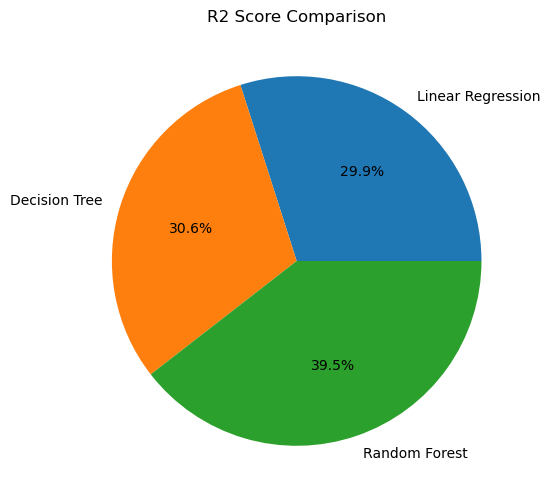

In [53]:
labels=['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores=[0.6139, 0.6275, 0.8101]

plt.figure(figsize=(6,6))
plt.pie(r2_scores,labels=labels,autopct='%1.1f%%')

plt.title('R2 Score Comparison')
plt.show()

## Hyperparameter Tuning

In [55]:
param_grid={'n_estimators':[100,200],'max_depth':[10,20,None],'min_samples_split':[2,5]}

In [56]:
grid=GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [57]:
grid.best_params_

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

In [58]:
best_model=grid.best_estimator_
pred=best_model.predict(x_test)
print("R2 Score :",r2_score(y_test,pred))

R2 Score : 0.811551868725521


## Feature Importance

In [60]:
importance=pd.DataFrame({
    'Feature':x.columns,
    'Importance':best_model.feature_importances_
})
importance=importance.sort_values(by='Importance',ascending=False)

importance.head(10)

,Feature,Importance
7,median_income,0.522141
0,longitude,0.155381
1,latitude,0.147160
2,housing_median_age,0.065397
5,population,0.037384
4,total_bedrooms,0.028671
3,total_rooms,0.024279
6,households,0.019586


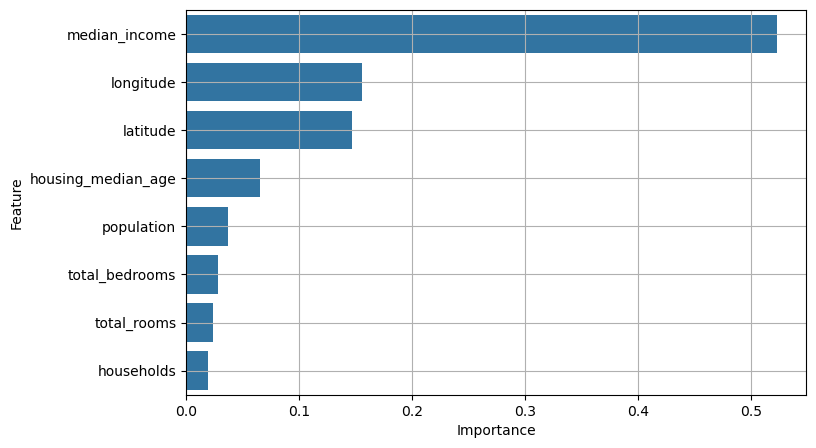

In [61]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance",y="Feature",data=importance.head(10))
plt.grid()

# Predictions

In [63]:
new_house=pd.DataFrame({
    'longitude':[-122.25,-121.50,-118.20,-119.10,-120.50],
    'latitude':[37.85,36.50,34.10,35.80,36.20],
    'housing_median_age':[25,20,18,30,15],
    'total_rooms':[2500,1800,3000,2200,2700],
    'total_bedrooms':[450,350,600,500,520],
    'population':[900,700,1200,850,1000],
    'households':[400,320,500,410,450],
    'median_income':[5.2,4.5,7.1,5.8,6.0]
})

In [64]:
new_scaled=scaler.transform(new_house)

In [65]:
pred=best_model.predict(new_scaled)
print(pred)

[128222.  132647.  130318.  127043.  129304.5]


# Conclusion

#### 1. Which model performed best?

Random Forest Regressor because it achieved the highest R² score and the lowest prediction error after hyperparameter tuning

#### 2. Which features have the highest impact?

Median Income

#### 3. Challenges Faced

* Missing values in total_bedrooms
* Handling of outliers
* House prices are limited to 500000

#### 4. How can the model be improved?

* Handle missing values properly
* Create new useful features (feature selection)
* Tune the model for better accuracy

## Key Insights:
* Most of the values are low,and only a few values are very high(Right-skewed)
* Median Income has a very a few high values(Outliers)
* Most house prices are less than 50000
* Many outliers exist.
* Total rooms and population have extreme values.
* Median income also contains outliers.
* Some house ages appear more frequently
* Older houses are common
* Median income has the highest positive correlation with house price.
* Latitude,longitude and population show negative relationships.
* Housing_median_age,total_rooms and households show week positve correlation
* toatal_bedrooms have very week positive correlation
* As median_income increases house prices also increases
* Higher-icome have expensive houses
* most house prices are below 500000

In [127]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load trained model and scaler
model = joblib.load("house_price_model.pkl")
scaler = joblib.load("scaler.pkl")

# Page title
st.title("🏠 House Price Prediction")

st.write("Enter the house details below to predict the house price.")

# Input fields
longitude = st.number_input("Longitude")
latitude = st.number_input("Latitude")
housing_median_age = st.number_input("Housing Median Age")
total_rooms = st.number_input("Total Rooms")
total_bedrooms = st.number_input("Total Bedrooms")
population = st.number_input("Population")
households = st.number_input("Households")
median_income = st.number_input("Median Income")

# Prediction
if st.button("Predict Price"):

    data = pd.DataFrame({
        "longitude": [longitude],
        "latitude": [latitude],
        "housing_median_age": [housing_median_age],
        "total_rooms": [total_rooms],
        "total_bedrooms": [total_bedrooms],
        "population": [population],
        "households": [households],
        "median_income": [median_income]
    })

    # Scale input
    data_scaled = scaler.transform(data)

    # Predict
    prediction = model.predict(data_scaled)

    st.success(f"Predicted House Price: ${prediction[0]:,.2f}")

Overwriting app.py


In [129]:
import joblib

joblib.dump(best_model, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [131]:
import os
os.listdir()

['.ipynb_checkpoints',
 'All Classifcation Model on Heart Classification(P Mahalaxmi Reddy).ipynb',
 'All Regression on Housing.ipynb',
 'app.py',
 'Boosting Technique(AdaBoost,XGBoosting).ipynb',
 'Decision Tree Classification.ipynb',
 'Decision Tree Regression.ipynb',
 'Encoding.ipynb',
 'Feature Scaling.ipynb',
 'house_price_model.pkl',
 'Housing Project(P Mahalaxmi Reddy).ipynb',
 'K-mean Clustering.ipynb',
 'KNN on Wine_clean(P MahalaxmiReddy) .ipynb',
 'KNN.ipynb',
 'LinearRegression Project.ipynb',
 'LogisticRegression model titanic(Mahalaxmi).ipynb',
 'LogisticRegression on Heart Classification(P Mahalaxmi Reddy).ipynb',
 'LogisticRegression.ipynb',
 'LR(Polynomial Regression).ipynb',
 'LR-Assigment.ipynb',
 'Multi LinearRegression.ipynb',
 'MultiLinearRegression Project.ipynb',
 'PCA.ipynb',
 'RandomForest on winequality-red.ipynb',
 'RandomForest.ipynb',
 'scaler.pkl',
 'simple linear regression.ipynb',
 'SVM Classification and Regression.ipynb',
 'SVM on breast-cancer(P Maha

In [133]:
%%writefile requirements.txt

pandas
numpy
scikit-learn
streamlit
joblib

Writing requirements.txt
